Готовая база для Markdown:
v1.2: https://drive.google.com/file/d/17-_-kA8SVuAU5OM_2gkzGqw_lZ0Zc4yo/view?usp=sharing

In [ ]:
!pip install -q langchain_openai==0.0.2 faiss-cpu==1.7.4 openai==1.6.1 tiktoken==0.5.2 langchain_community==0.0.11 langchain==0.1.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 20.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.4/225.4 kB 15.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 48.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.0/798.0 kB 28.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.3/291.3 kB 15.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.2/290.2 kB 13.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from langchain_openai import OpenAIEmbeddings
from langchain.text_splitter import CharacterTextSplitter
from langchain.vectorstores import FAISS
from langchain.text_splitter import RecursiveCharacterTextSplitter, MarkdownHeaderTextSplitter
import re
import requests
import openai
from openai import OpenAI
import os
from langchain.docstore.document import Document
import tiktoken
import matplotlib.pyplot as plt
from google.colab import userdata

In [ ]:
# Получение API ключа из пользовательских данных Colab и установка его как переменной среды
key = userdata.get('OPENAI_API_KEY')
os.environ["OPENAI_API_KEY"] = key

# Создание клиента OpenAI с использованием API ключа из переменных среды
client = OpenAI()

In [ ]:
# База знаний для Markdown сохранена в файле doc_markdown_v1.2.txt, его ID 17-_-kA8SVuAU5OM_2gkzGqw_lZ0Zc4yo
id_doc_markdown = '17-_-kA8SVuAU5OM_2gkzGqw_lZ0Zc4yo'

In [ ]:
# функция для загрузки документа по doc_id из гугл драйв в текстовом формате
def load_doc_id_text(file_id):
    # Download the document as plain text
    response = requests.get(f'https://drive.google.com/uc?export=download&id={file_id}')
    response.raise_for_status()
    text = response.text

    return text

In [ ]:
data_from_markdown = load_doc_id_text(id_doc_markdown)

In [ ]:
data_from_markdown[-100:]

'я информации на оборотной стороне свидетельства о поверке при оформлении его на бумажном носителе).\n'

In [ ]:
def num_tokens_from_string(string: str, encoding_name: str) -> int:
      """Возвращает количество токенов в строке"""
      encoding = tiktoken.get_encoding(encoding_name)
      num_tokens = len(encoding.encode(string))
      return num_tokens

def split_text(text, max_count):
    headers_to_split_on = [
        ("#", "Header 1"),
        ("##", "Header 2"),
        ("###", "Header 3"),
        ("####", "Header 4"),
    ]

    markdown_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
    fragments = markdown_splitter.split_text(text)

    # Подсчет токенов для каждого фрагмента и построение графика
    fragment_token_counts = [num_tokens_from_string(fragment.page_content, "cl100k_base") for fragment in fragments]
    plt.hist(fragment_token_counts, bins=50, alpha=0.5, label='Fragments')
    plt.title('Распределение количества фрагментных токенов')
    plt.xlabel('Количество токенов')
    plt.ylabel('Частота')
    plt.show()

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=max_count,
        chunk_overlap=0,
        length_function=lambda x: num_tokens_from_string(x, "cl100k_base")
    )

    source_chunks = [
        Document(page_content=chunk, metadata=fragment.metadata)
        for fragment in fragments
        for chunk in splitter.split_text(fragment.page_content)
    ]

    # Подсчет токенов для каждого source_chunk и построение графика
    source_chunk_token_counts = [num_tokens_from_string(chunk.page_content, "cl100k_base") for chunk in source_chunks]
    plt.hist(source_chunk_token_counts, bins=20, alpha=0.5, label='Source Chunks')
    plt.title('Распределение количества токенов исходного блока')
    plt.xlabel('Количество токенов')
    plt.ylabel('Частота')
    plt.show()

    return source_chunks, fragments

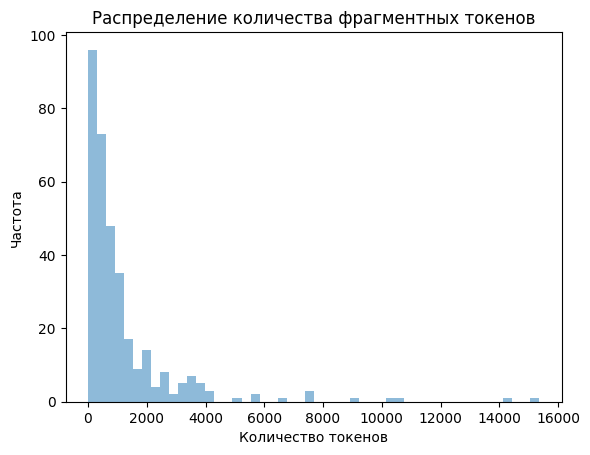

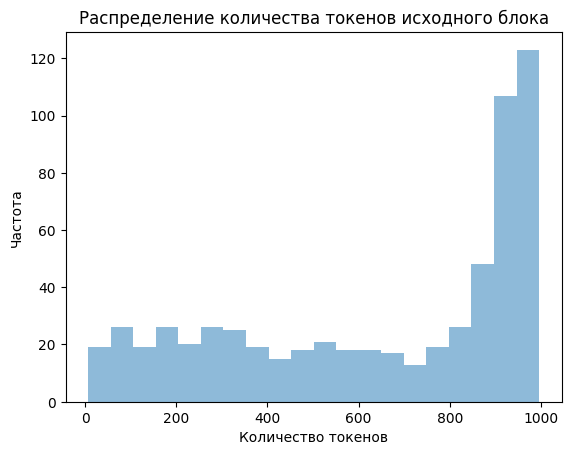

Общее количество чанков:  623
Первый чанк  page_content='Документ предоставлен КонсультантПлюс'
Крайний чанк  page_content='5. На оборотной стороне свидетельств о поверке при оформлении их на бумажном носителе или в свидетельствах о поверке, оформляемых в виде электронного документа, по заявлению владельцев средств измерений или лиц, представивших средства измерений на поверку, или по согласованию с ними может указываться дополнительная информация, относящаяся к средствам измерений, месту их установки, особенностям поверки, включая сведения о пломбах, предотвращающих доступ к местам настройки (регулировки) средств измерений, принадлежности средств измерений (сведения о владельцах средств измерений), а также информация о прилагаемых к свидетельству о поверке документах (при невозможности размещения информации на оборотной стороне свидетельства о поверке при оформлении его на бумажном носителе).' metadata={'Header 1': 'ТРЕБОВАНИЯ К СОДЕРЖАНИЮ СВИДЕТЕЛЬСТВА О ПОВЕРКЕ'}


In [ ]:
source_chunks, fragments = split_text(data_from_markdown, 1000)
print("Общее количество чанков: ",len(source_chunks))
print("Первый чанк ", source_chunks[0])
print("Крайний чанк ", source_chunks[len(source_chunks)-1])

In [ ]:
# Инструкция в system
system = "Ты юридический консультант по метрологическому обеспечению, ответь на вопрос клиента на основе документа с информацией. При ответе ссылайся на статьи, главы и пункты нормативной документации, указаннай в заголовке документа. Не указывай из какого отрывка документа взята информация (Так ответчать не нужно: 'Из документа №2 следует...'). Не придумывай ничего от себя, отвечай максимально по представленным документам. Не отвечай на вопросы, не касающиеся документа."

In [ ]:
# Инициализирум модель эмбеддингов
embeddings = OpenAIEmbeddings()

# Создадим индексную базу из разделенных фрагментов текста
db = FAISS.from_documents(source_chunks, embeddings)

In [ ]:
def answer_index(system, topic, search_index, verbose=0):

    # Поиск релевантных отрезков из базы знаний
    docs = search_index.similarity_search(topic, k=4)
    if verbose: print('\n ===========================================: ')
    #message_content = re.sub(r'\n{2}', ' ', '\n '.join([f'\n =======\nОтрывок документа №{i+1}\n=====================' + doc.page_content + '\n' for i, doc in enumerate(docs)]))
    message_content = re.sub(r'\n{2}', ' ', '\n '.join([f'\n =======\nОтрывок документа №{i+1}\n=====' + str(doc.metadata) + '\n================' + str(doc.page_content) + '\n' for i, doc in enumerate(docs)]))
    if verbose: print('message_content :\n ======================================== \n', message_content)
    client = OpenAI()
    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": f"Ответь на вопрос. Документ с информацией для ответа: {message_content}\n\nВопрос пользователя: \n{topic}"}
    ]

    if verbose: print('\n ===========================================: ')

    completion = client.chat.completions.create(
        model="gpt-3.5-turbo-1106",
        messages=messages,
        temperature=0                           # укажите температуру
    )
    answer = completion.choices[0].message.content
    return message_content, answer  # возвращает ответ

#Проверяем работу нейро-консультанта на вопросах из базы doc_markdown_v1.2.txt

In [ ]:
# 1 вопрос пользователя О пломбировании манометров
topic= "В настоящий момент в нашей организации находятся в эксплуатации технические манометры утвержденного типа, прошедшие поверку в соответствии с положениями ФЗ № 102-ФЗ в конструктивном исполнении, не предусматривающем места установки пломб, содержащих изображение знака поверки. Сведения о месте установки пломб в том числе отсутствуют в описании типа СИ на манометры. Прошу Вас дать разъяснение о соответствии таких средств измерений требованиям ФЗ № 102-ФЗ и возможности их применения для измерений, на которые распространяется сфера государственного регулирования обеспечения единства измерений."
message, ans = answer_index(system, topic, db)
print(message)
print(f'\n =======\nОтвет GPT:\n{ans}')


Отрывок документа №1
====={'Header 1': 'МИНИСТЕРСТВО ПРОМЫШЛЕННОСТИ И ТОРГОВЛИ РОССИЙСКОЙ ФЕДЕРАЦИИ ПРИКАЗ от 31 июля 2020 г. N 2510 ОБ УТВЕРЖДЕНИИ ПОРЯДКА ПРОВЕДЕНИЯ ПОВЕРКИ СРЕДСТВ ИЗМЕРЕНИЙ, ТРЕБОВАНИЙ К ЗНАКУ ПОВЕРКИ И СОДЕРЖАНИЮ СВИДЕТЕЛЬСТВА О ПОВЕРКЕ', 'Header 2': 'II. Организация поверки средств измерений и представление средств измерений на поверку'}
================повреждения или отсутствия пломб, обеспечивающих защиту от несанкционированного доступа к узлам настройки (регулировки) средств измерений, с вскрытием пломб, предотвращающих доступ к узлам настройки (регулировки) и (или) элементам конструкции средств измерений.
В добровольном порядке средства измерений на внеочередную поверку могут представляться без ограничений количества представлений и сроков представления в течение межповерочного интервала.
7. Средства измерений должны представляться на поверку:
очищенными от загрязнений и консервационных смазок;
с эксплуатационными документами, установленными при утверждении 

In [ ]:
# 2 вопрос пользователя О передаче сведений о поверке в Фонд
topic= "В мае купили прибор учета воды с отметкой о заводской поверке от 20.05.2022, 22 июля установили. Вопрос, как внести сведения о поверке в Федеральный информационный фонд по обеспечению единства измерений?"
message, ans = answer_index(system, topic, db)
print(message)
print(f'\n =======\nОтвет GPT:\n{ans}')


Отрывок документа №1
====={'Header 1': 'ПРАВИТЕЛЬСТВО РОССИЙСКОЙ ФЕДЕРАЦИИ ПОСТАНОВЛЕНИЕ от 20 апреля 2010 г. N 250 О ПЕРЕЧНЕ СРЕДСТВ ИЗМЕРЕНИЙ, ПОВЕРКА КОТОРЫХ ОСУЩЕСТВЛЯЕТСЯ ТОЛЬКО АККРЕДИТОВАННЫМИ В УСТАНОВЛЕННОМ ПОРЯДКЕ В ОБЛАСТИ ОБЕСПЕЧЕНИЯ ЕДИНСТВА ИЗМЕРЕНИЙ ГОСУДАРСТВЕННЫМИ РЕГИОНАЛЬНЫМИ ЦЕНТРАМИ МЕТРОЛОГИИ', 'Header 2': 'Статья 13. Поверка средств измерений'}
================6. Сведения о результатах поверки средств измерений передаются в Федеральный информационный фонд по обеспечению единства измерений проводящими поверку средств измерений юридическими лицами и индивидуальными предпринимателями в срок, установленный в порядке, предусмотренном частью 5 настоящей статьи. Состав сведений о результатах поверки средств измерений и порядок включения указанных сведений в Федеральный информационный фонд по обеспечению единства измерений определяются в порядке, утверждаемом федеральным органом исполнительной власти, осуществляющим функции по выработке государственной политики и нормат

In [ ]:
# вопрос пользователя О порядке утверждения типа
topic= "Нужно внести в реестр Минпромторга металлические линейки, сделанные по госту и поставленные по государственному контракту. Что нам для этого нужно?"
message, ans = answer_index(system, topic, db)
print(message)
print(f'\n =======\nОтвет GPT:\n{ans}')


Отрывок документа №1
====={'Header 1': 'МИНИСТЕРСТВО ПРОМЫШЛЕННОСТИ И ТОРГОВЛИ РОССИЙСКОЙ ФЕДЕРАЦИИ ФЕДЕРАЛЬНОЕ АГЕНТСТВО ПО ТЕХНИЧЕСКОМУ РЕГУЛИРОВАНИЮ И МЕТРОЛОГИИ ПРИКАЗ от 12 ноября 2018 г. N 2346 ОБ УТВЕРЖДЕНИИ АДМИНИСТРАТИВНОГО РЕГЛАМЕНТА ПО ПРЕДОСТАВЛЕНИЮ ФЕДЕРАЛЬНЫМ АГЕНТСТВОМ ПО ТЕХНИЧЕСКОМУ РЕГУЛИРОВАНИЮ И МЕТРОЛОГИИ ГОСУДАРСТВЕННОЙ УСЛУГИ ПО УТВЕРЖДЕНИЮ ТИПА СТАНДАРТНЫХ ОБРАЗЦОВ ИЛИ ТИПА СРЕДСТВ ИЗМЕРЕНИЙ', 'Header 3': 'Органы государственной власти, организации и уполномоченные на рассмотрение жалобы лица, которым может быть направлена жалоба Заявителя в досудебном (внесудебном) порядке'}
================Если заинтересованные лица не удовлетворены решением, принятым в ходе рассмотрения жалобы должностными лицами Росстандарта (или решение ими не было принято), и (или) действием (бездействием), то заинтересованные лица вправе обратиться в Минпромторг России письменно почтовым отправлением или посредством официального сайта Минпромторга России в информационно-телекоммуникацион

In [ ]:
# вопрос пользователя Трансформаторы_ТПЛ-10
topic= "Поверители не выдают свидетельство о поверке (т.е. они их бракуют) на трансформаторы тока, ссылаясь на то, что во ФГИСе в утвержденных типах средств измерений фигурирует другой изготовитель. Насколько правомерны такие действия и что можно предпринять для решения проблемы."
message, ans = answer_index(system, topic, db)
print(message)
print(f'\n =======\nОтвет GPT:\n{ans}')


Отрывок документа №1
====={'Header 1': 'ТРЕБОВАНИЯ К СОДЕРЖАНИЮ СВИДЕТЕЛЬСТВА О ПОВЕРКЕ'}
================5. На оборотной стороне свидетельств о поверке при оформлении их на бумажном носителе или в свидетельствах о поверке, оформляемых в виде электронного документа, по заявлению владельцев средств измерений или лиц, представивших средства измерений на поверку, или по согласованию с ними может указываться дополнительная информация, относящаяся к средствам измерений, месту их установки, особенностям поверки, включая сведения о пломбах, предотвращающих доступ к местам настройки (регулировки) средств измерений, принадлежности средств измерений (сведения о владельцах средств измерений), а также информация о прилагаемых к свидетельству о поверке документах (при невозможности размещения информации на оборотной стороне свидетельства о поверке при оформлении его на бумажном носителе).  
Отрывок документа №2
====={'Header 1': 'ПОРЯДОК УТВЕРЖДЕНИЯ ТИПА СТАНДАРТНЫХ ОБРАЗЦОВ ИЛИ ТИПА СРЕДСТВ ИЗМЕР

In [ ]:
# вопрос пользователя О сведениях из Фонда об идентичности СИ
topic= 'Согласно ФЗ № 102 "Об обеспечении единства средств измерений" сведения о типах и средствах измерений вносятся в Федеральный информационный фонд по обеспечению единства средств измерений. Согласно пункту 4 приказа Минпромторга России № 2906 от 28.08.2020 "Об утверждении порядка создания и ведения Федерального информационного фонда по обеспечению единства измерений, передачи сведений в него и внесения изменений в данные сведений, предоставления содержащихся в нем документов и сведений" организация ведения данного Фонда возложена на Федерального агентство по техническому регулированию и метрологии. В связи с этим прошу в ответном письме указать являются ли сходными (идентичными, имеющими одинаковый метод работы, способы поверки) типы средств измерений, зарегистрированные в Фонде под различными номерами.'
message, ans = answer_index(system, topic, db)
print(message)
print(f'\n =======\nОтвет GPT:\n{ans}')


Отрывок документа №1
====={'Header 1': 'ПРАВИТЕЛЬСТВО РОССИЙСКОЙ ФЕДЕРАЦИИ ПОСТАНОВЛЕНИЕ от 20 апреля 2010 г. N 250 О ПЕРЕЧНЕ СРЕДСТВ ИЗМЕРЕНИЙ, ПОВЕРКА КОТОРЫХ ОСУЩЕСТВЛЯЕТСЯ ТОЛЬКО АККРЕДИТОВАННЫМИ В УСТАНОВЛЕННОМ ПОРЯДКЕ В ОБЛАСТИ ОБЕСПЕЧЕНИЯ ЕДИНСТВА ИЗМЕРЕНИЙ ГОСУДАРСТВЕННЫМИ РЕГИОНАЛЬНЫМИ ЦЕНТРАМИ МЕТРОЛОГИИ', 'Header 2': 'Статья 12. Утверждение типа стандартных образцов или типа средств измерений'}
================6. Сведения об утвержденных типах стандартных образцов и типах средств измерений, о внесенных в них изменениях включаются в Федеральный информационный фонд по обеспечению единства измерений в порядке, устанавливаемом федеральным органом исполнительной власти, осуществляющим функции по выработке государственной политики и нормативно-правовому регулированию в области обеспечения единства измерений, в соответствии с частью 3 статьи 20 настоящего Федерального закона. Состав сведений о типах стандартных образцов и типах средств измерений, включаемых в Федеральный информаци

In [ ]:
# вопрос пользователя О чем ПРИКАЗ от 28 августа 2020 г. N 2906 - а ответ то не находится(((
topic= 'О чем ПРИКАЗ от 28 августа 2020 г. N 2906'
message, ans = answer_index(system, topic, db)
print(message)
print(f'\n =======\nОтвет GPT:\n{ans}')


Отрывок документа №1
====={'Header 1': 'МИНИСТЕРСТВО ПРОМЫШЛЕННОСТИ И ТОРГОВЛИ РОССИЙСКОЙ ФЕДЕРАЦИИ ПРИКАЗ от 25 июня 2013 г. N 971 ОБ УТВЕРЖДЕНИИ АДМИНИСТРАТИВНОГО РЕГЛАМЕНТА ПО ПРЕДОСТАВЛЕНИЮ ФЕДЕРАЛЬНЫМ АГЕНТСТВОМ ПО ТЕХНИЧЕСКОМУ РЕГУЛИРОВАНИЮ И МЕТРОЛОГИИ ГОСУДАРСТВЕННОЙ УСЛУГИ ПО ОТНЕСЕНИЮ ТЕХНИЧЕСКИХ СРЕДСТВ К СРЕДСТВАМ ИЗМЕРЕНИЙ', 'Header 2': 'III. Состав, последовательность и сроки выполнения административных процедур (действий), требования к порядку их выполнения, в том числе особенности выполнения административных процедур (действий) в электронной форме'}
================(в ред. Приказа Минпромторга России от 23.08.2017 N 2872)  
Отрывок документа №2
====={'Header 1': 'ПОРЯДОК ВЫДАЧИ СЕРТИФИКАТОВ ОБ УТВЕРЖДЕНИИ ТИПА СТАНДАРТНЫХ ОБРАЗЦОВ ИЛИ ТИПА СРЕДСТВ ИЗМЕРЕНИЙ'}
================техническому регулированию и метрологии от ____________ N __________.
должность уполномоченного подпись расшифровка подписи
лица
_______________________________ ________________ ___________________

In [ ]:
# вопрос пользователя Почему идет дождь?
topic= 'Почему идет дождь?'
message, ans = answer_index(system, topic, db)
print(message)
print(f'\n =======\nОтвет GPT:\n{ans}')


Отрывок документа №1
====={'Header 1': 'МЕЖГОСУДАРСТВЕННЫЙ СОВЕТ ПО СТАНДАРТИЗАЦИИ, МЕТРОЛОГИИ И СЕРТИФИКАЦИИ INTERSTATE COUNCIL FOR STANDARDIZATION, METROLOGY AND CERTIFICATION МЕЖГОСУДАРСТВЕННЫЙ СТАНДАРТ ГОСТ ISO/IEC 17025-2019 ОБЩИЕ ТРЕБОВАНИЯ К КОМПЕТЕНТНОСТИ ИСПЫТАТЕЛЬНЫХ И КАЛИБРОВОЧНЫХ ЛАБОРАТОРИЙ (ISO/IEC 17025:2017, IDT) General requirements for the competence of testing and calibration laboratories', 'Header 2': 'A.1 Общие сведения'}
================В настоящем приложении приведена дополнительная информация о метрологической прослеживаемости, которая представляет собой важнейшую концепцию для обеспечения сопоставимости результатов измерений как на национальном, так и на международном уровне.  
Отрывок документа №2
====={'Header 1': 'ПРАВИТЕЛЬСТВО РОССИЙСКОЙ ФЕДЕРАЦИИ ПОСТАНОВЛЕНИЕ от 17 июня 2004 г. N 294 О ФЕДЕРАЛЬНОМ АГЕНТСТВЕ ПО ТЕХНИЧЕСКОМУ РЕГУЛИРОВАНИЮ И МЕТРОЛОГИИ'}
================7. Признать утратившим силу Постановление Правительства Российской Федерации от 8 апрел